# Lab-work #3

First name     - Maksym

Second name    - Maliutin

Group          - CS-31

## Selected dataset

**horses_or_humans** from TensorFlow Datasets.

## Goal

Build ConvNet models from scratch, compare them, then apply transfer learning and explain predictions.

# Task plan

1. Load and inspect the dataset.
2. Prepare images for training.
3. Train several ConvNet architectures from scratch.
4. Compare their performance.
5. Apply transfer learning.
6. Compare with custom CNN models.
7. Add explainability with saliency maps / SHAP if possible.
8. Write conclusions.

# 1. Install and import dependencies

In [1]:
%pip install tensorflow-datasets
%pip install importlib_resources
%pip install tensorflow==2.20.0
%pip install numpy==2.3.3
%pip install matplotlib==3.10.6
%pip install seaborn==0.13.2
%pip install scikit-learn==1.7.2

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style('darkgrid')
np.random.seed(42)
tf.random.set_seed(42)

print('Libraries imported successfully')

Libraries imported successfully


# 2. Load the dataset

In [3]:
ds_train, ds_info = tfds.load(
    'horses_or_humans',
    split='train',
    with_info=True,
    as_supervised=True
)

print(ds_info)

tfds.core.DatasetInfo(
    name='horses_or_humans',
    full_name='horses_or_humans/3.0.0',
    description="""
    A large set of images of horses and humans.
    """,
    homepage='http://laurencemoroney.com/horses-or-humans-dataset',
    data_dir='C:\\Users\\SystemX\\tensorflow_datasets\\horses_or_humans\\3.0.0',
    file_format=tfrecord,
    download_size=153.59 MiB,
    dataset_size=153.53 MiB,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=256, num_shards=1>,
        'train': <SplitInfo num_examples=1027, num_shards=2>,
    },
    citation="""@ONLINE {horses_or_humans,
    author = "Laurence Moroney",
    title = "Horses or Humans Dataset",
    month = "feb",
    year = "2019",
    url = "http://laurencemoroney.com

In [4]:
print('Dataset info:')
print('Number of classes:', ds_info.features['label'].num_classes)
print('Class names:', ds_info.features['label'].names)
print('Image shape:', ds_info.features['image'].shape)
print('Approximate dataset size:', ds_info.splits['train'].num_examples)

Dataset info:
Number of classes: 2
Class names: ['horses', 'humans']
Image shape: (300, 300, 3)
Approximate dataset size: 1027


# 3. Visualize samples

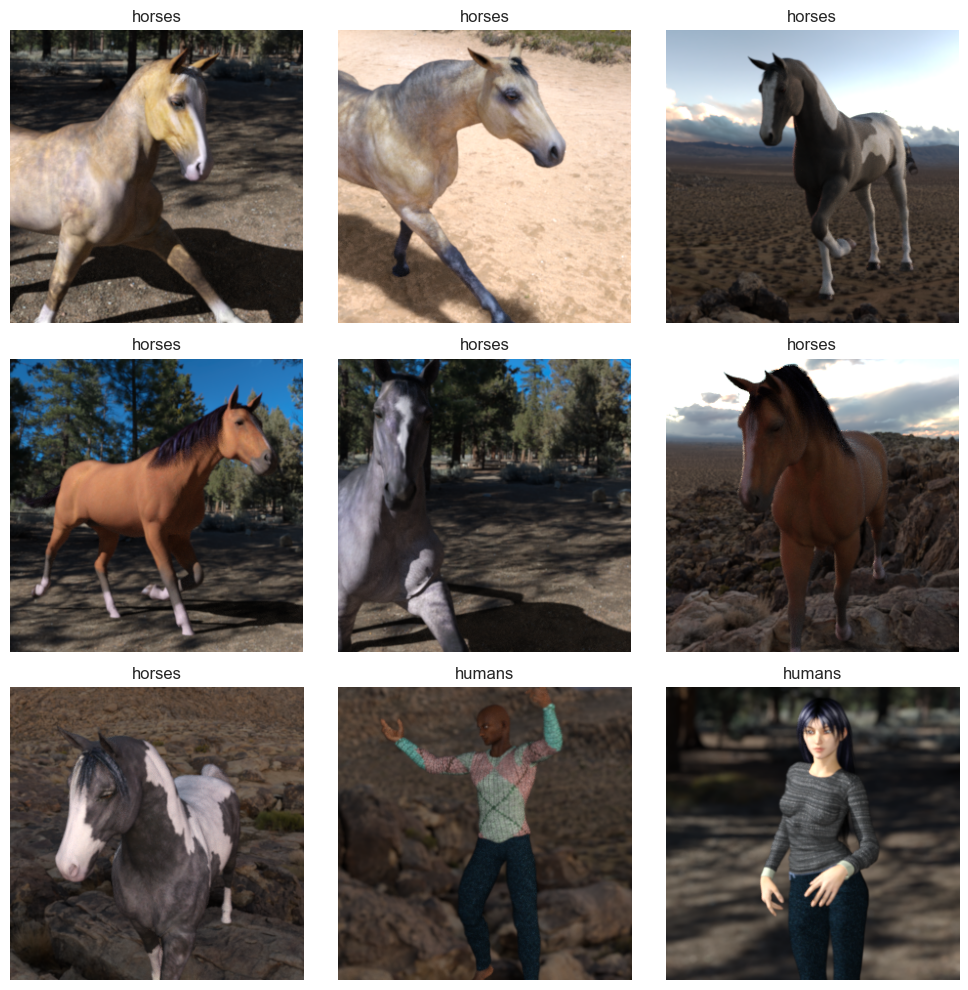

In [5]:
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(ds_train.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy().astype('uint8'))
    plt.title(ds_info.features['label'].names[label.numpy()])
    plt.axis('off')
plt.tight_layout()
plt.show()

# 4. Prepare data pipeline

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def resize_and_rescale(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [7]:
ds_train_prepared = ds_train.map(resize_and_rescale).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for images, labels in ds_train_prepared.take(1):
    print('Batch image shape:', images.shape)
    print('Batch label shape:', labels.shape)

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)


# 5. Train / validation / test split

In [8]:
# Shuffle once and create train / validation / test splits
num_examples = ds_info.splits['train'].num_examples
train_size = int(0.7 * num_examples)
val_size = int(0.15 * num_examples)
test_size = num_examples - train_size - val_size

full_ds = ds_train.shuffle(num_examples, seed=42, reshuffle_each_iteration=False)

ds_train_raw = full_ds.take(train_size)
ds_val_raw = full_ds.skip(train_size).take(val_size)
ds_test_raw = full_ds.skip(train_size + val_size)

print('Dataset sizes:')
print('Train:', train_size)
print('Validation:', val_size)
print('Test:', test_size)

# Preprocess for CNN training
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train_prepared = ds_train_raw.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_val_prepared = ds_val_raw.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test_prepared = ds_test_raw.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print('Prepared datasets are ready.')

Dataset sizes:
Train: 718
Validation: 154
Test: 155
Prepared datasets are ready.


# 6. Data augmentation

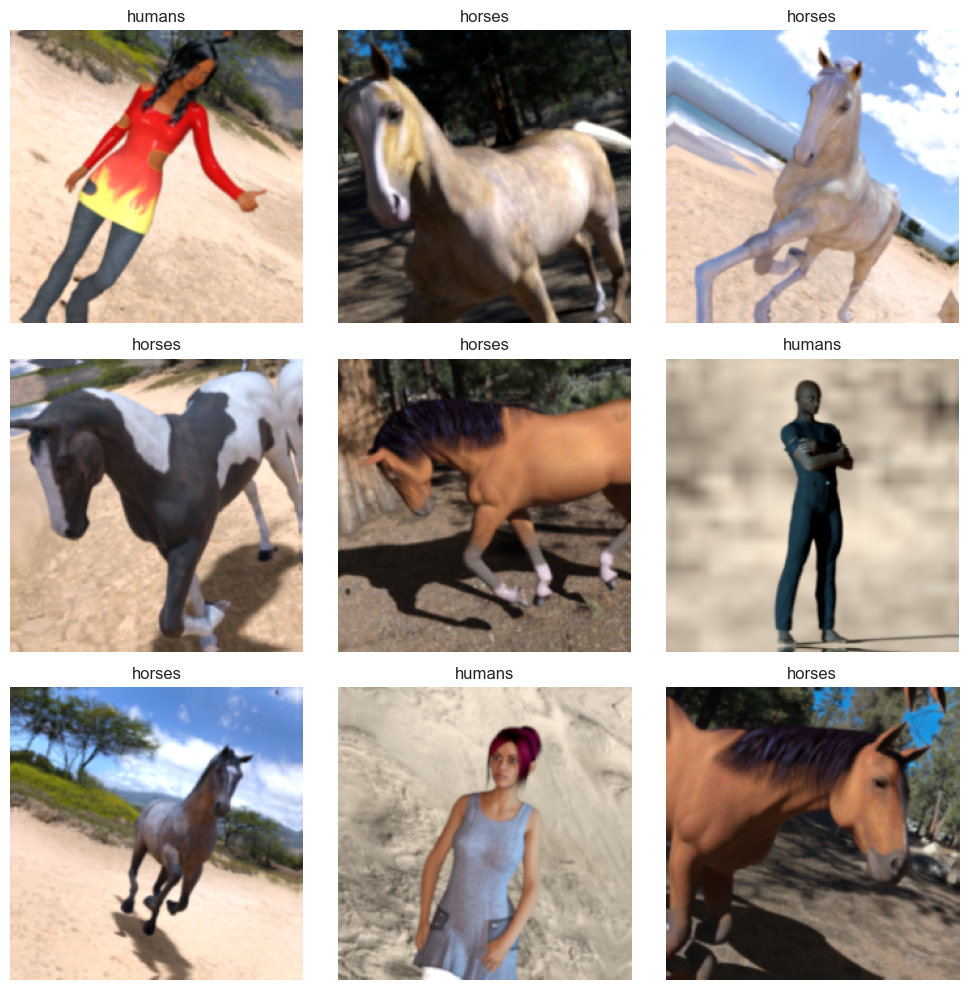

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='data_augmentation')

plt.figure(figsize=(10, 10))
for images, labels in ds_train_prepared.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy())
        plt.title(ds_info.features['label'].names[labels[i].numpy()])
        plt.axis('off')
plt.tight_layout()
plt.show()

# 7. Experiments with the Conv ANN from scratch

In [10]:
def build_cnn_v1():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ], name='cnn_v1')
    return model

cnn_v1 = build_cnn_v1()
cnn_v1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
cnn_v1.summary()

Model: "cnn_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 388ms/step - accuracy: 0.5961 - loss: 1.0367 - val_accuracy: 0.7857 - val_loss: 0.4754
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 369ms/step - accuracy: 0.8440 - loss: 0.3435 - val_accuracy: 0.9416 - val_loss: 0.1372
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 360ms/step - accuracy: 0.8983 - loss: 0.2376 - val_accuracy: 0.9481 - val_loss: 0.1123
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 359ms/step - accuracy: 0.9318 - loss: 0.1715 - val_accuracy: 0.8247 - val_loss: 0.3432
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 357ms/step - accuracy: 0.9276 - loss: 0.1996 - val_accuracy: 0.9675 - val_loss: 0.0796
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 369ms/step - accuracy: 0.9443 - loss: 0.1431 - val_accuracy: 0.9610 - val_loss: 0.1024
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 420ms/step - accuracy: 0.9638 - loss: 0.1154 - val_accuracy: 0.9675 - val_loss: 0.0825
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 411ms/step - accuracy: 0.9610 - loss: 0.0963 - val_accuracy: 

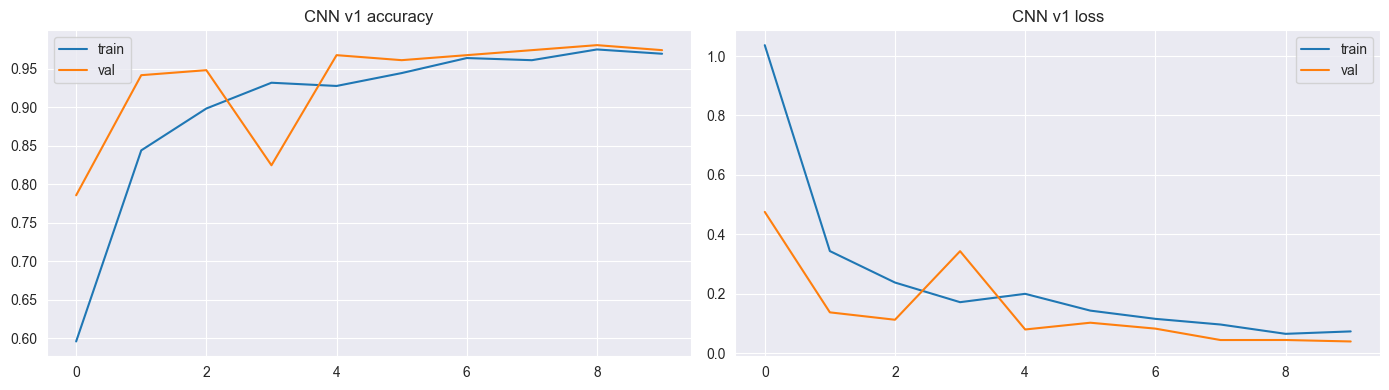

In [11]:
def plot_history(history, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['accuracy'], label='train')
    axes[0].plot(history.history['val_accuracy'], label='val')
    axes[0].set_title(f'{title_prefix} accuracy')
    axes[0].legend()
    
    axes[1].plot(history.history['loss'], label='train')
    axes[1].plot(history.history['val_loss'], label='val')
    axes[1].set_title(f'{title_prefix} loss')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

callbacks_list = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

history_v1 = cnn_v1.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=10,
    callbacks=callbacks_list,
    verbose=1
)

plot_history(history_v1, 'CNN v1')

Model: "cnn_v1_no_aug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 358ms/step - accuracy: 0.7396 - loss: 0.6637 - val_accuracy: 0.9610 - val_loss: 0.1470
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 366ms/step - accuracy: 0.9540 - loss: 0.1274 - val_accuracy: 0.9610 - val_loss: 0.1083
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 373ms/step - accuracy: 0.9763 - loss: 0.0657 - val_accuracy: 0.9740 - val_loss: 0.0600


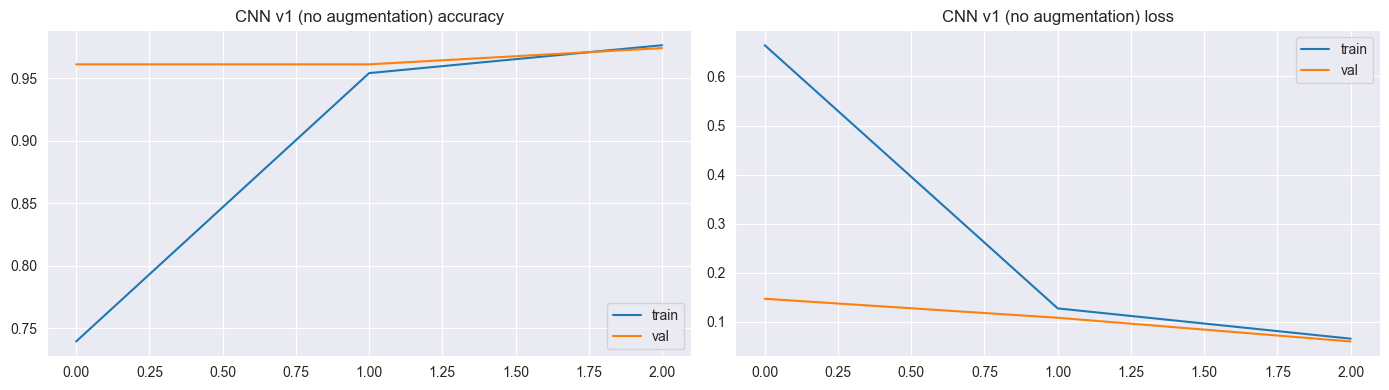

In [12]:
def build_cnn_v1_no_aug():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ], name='cnn_v1_no_aug')
    return model

cnn_v1_no_aug = build_cnn_v1_no_aug()
cnn_v1_no_aug.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_v1_no_aug.summary()

history_v1_no_aug = cnn_v1_no_aug.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=10,
    callbacks=callbacks_list,
    verbose=1
)

plot_history(history_v1_no_aug, 'CNN v1 (no augmentation)')

In [13]:
def build_cnn_v2():
    inputs = tf.keras.layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs, outputs, name='cnn_v2')
    return model

cnn_v2 = build_cnn_v2()
cnn_v2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_v2.summary()

Model: "cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,593 (1.49 MB)

 Trainable params: 389,633 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 922ms/step - accuracy: 0.7521 - loss: 0.5366 - val_accuracy: 0.5519 - val_loss: 0.7294
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 905ms/step - accuracy: 0.8496 - loss: 0.3325 - val_accuracy: 0.5519 - val_loss: 1.5161
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 895ms/step - accuracy: 0.9290 - loss: 0.2045 - val_accuracy: 0.5519 - val_loss: 2.3747


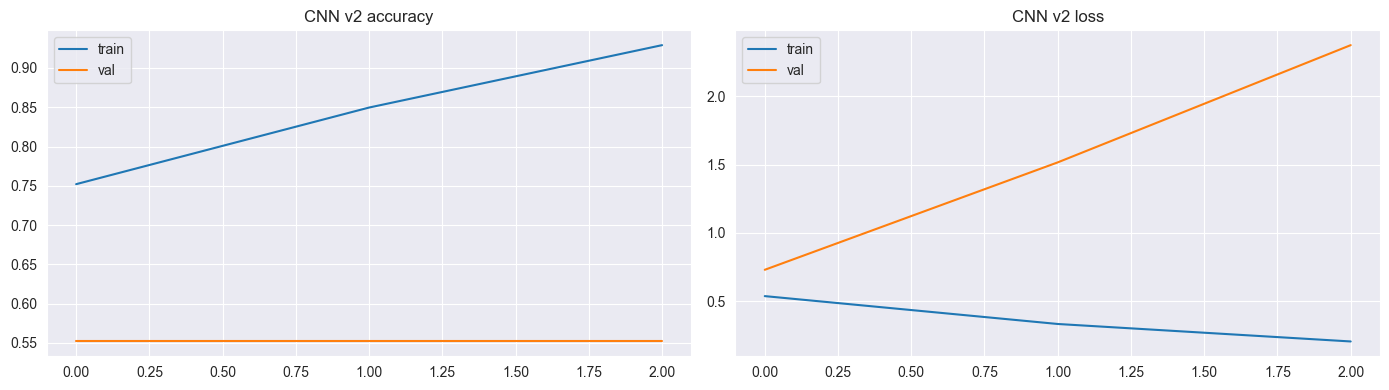

In [14]:
history_v2 = cnn_v2.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=10,
    callbacks=callbacks_list,
    verbose=1
)

plot_history(history_v2, 'CNN v2')

# 8. A smaller regularized CNN

Model: "cnn_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,809 (108.63 KB)

 Trainable params: 27,809 (108.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.4833 - loss: 0.6976 - val_accuracy: 0.5519 - val_loss: 0.6904
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.4944 - loss: 0.6898 - val_accuracy: 0.5584 - val_loss: 0.6863
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.5850 - loss: 0.6766 - val_accuracy: 0.6494 - val_loss: 0.6608


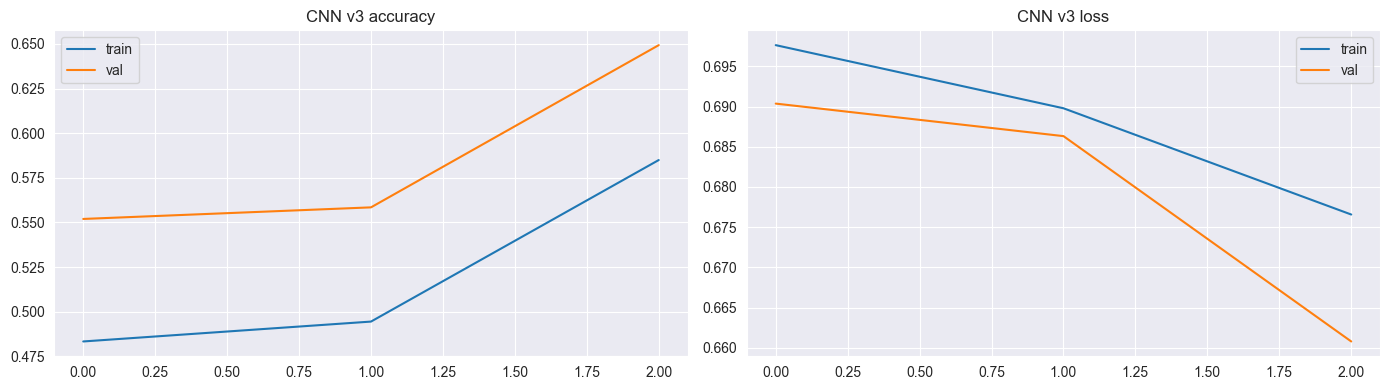

In [15]:
def build_cnn_v3():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ], name='cnn_v3')
    return model

cnn_v3 = build_cnn_v3()
cnn_v3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_v3.summary()

history_v3 = cnn_v3.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=10,
    callbacks=callbacks_list,
    verbose=1
)

plot_history(history_v3, 'CNN v3')

# 9. Compare CNN models

           model      loss  accuracy
0  CNN v1 no aug  0.147814  0.961290
1   CNN v1 + aug  0.006441  1.000000
2   CNN v2 + aug  0.778985  0.522581
3   CNN v3 + aug  0.690945  0.522581


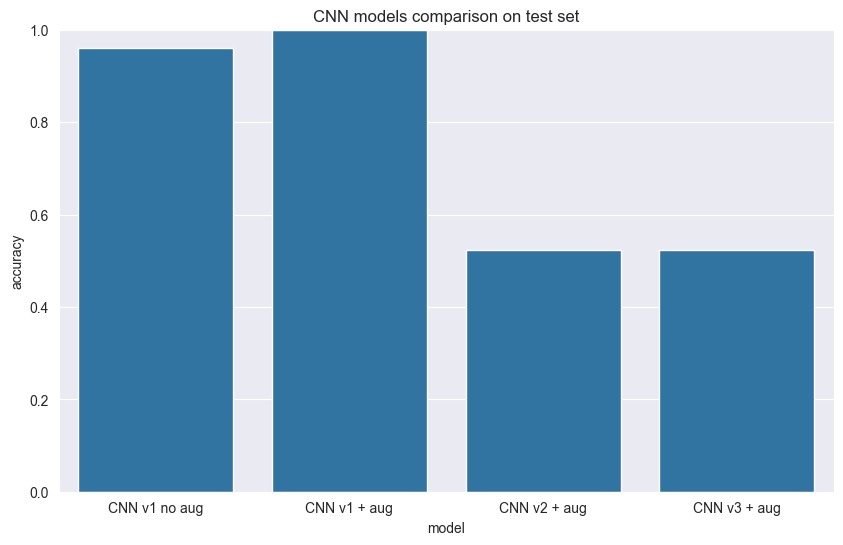

In [16]:
def evaluate_model(model, dataset, name):
    loss, acc = model.evaluate(dataset, verbose=0)
    return {'model': name, 'loss': loss, 'accuracy': acc}

results = [
    evaluate_model(cnn_v1_no_aug, ds_test_prepared, 'CNN v1 no aug'),
    evaluate_model(cnn_v1, ds_test_prepared, 'CNN v1 + aug'),
    evaluate_model(cnn_v2, ds_test_prepared, 'CNN v2 + aug'),
    evaluate_model(cnn_v3, ds_test_prepared, 'CNN v3 + aug'),
]
results_df = __import__('pandas').DataFrame(results)
print(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='model', y='accuracy')
plt.title('CNN models comparison on test set')
plt.ylim(0, 1)
plt.show()

# 10. Transfer learning

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


def preprocess_transfer(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

transfer_train = ds_train_raw.map(preprocess_transfer, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
transfer_val = ds_val_raw.map(preprocess_transfer, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
transfer_test = ds_test_raw.map(preprocess_transfer, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

base_model = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base_model.trainable = False

transfer_model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

transfer_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
transfer_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step - accuracy: 0.9095 - loss: 0.2970 - val_accuracy: 0.9935 - val_loss: 0.0882
Epoch 2/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step - accuracy: 0.9958 - loss: 0.0603 - val_accuracy: 0.9935 - val_loss: 0.0384
Epoch 3/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.9972 - loss: 0.0291 - val_accuracy: 0.9935 - val_loss: 0.0266
Epoch 4/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - accuracy: 0.9972 - loss: 0.0234 - val_accuracy: 0.9935 - val_loss: 0.0215
Epoch 5/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - accuracy: 0.9958 - loss: 0.0200 - val_accuracy: 0.9935 - val_loss: 0.0181
Epoch 6/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step - accuracy: 0.9986 - loss: 0.0123 - val_accuracy: 0.9935 - val_loss: 0.0152
Epoch 7/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - accuracy: 0.9972 - loss: 0.0129 - val_accuracy: 0.9935 - val_loss: 0.0135
Epoch 8/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step - accuracy: 0.9986 - loss: 0.0102 - val_accuracy: 1.0000 - v

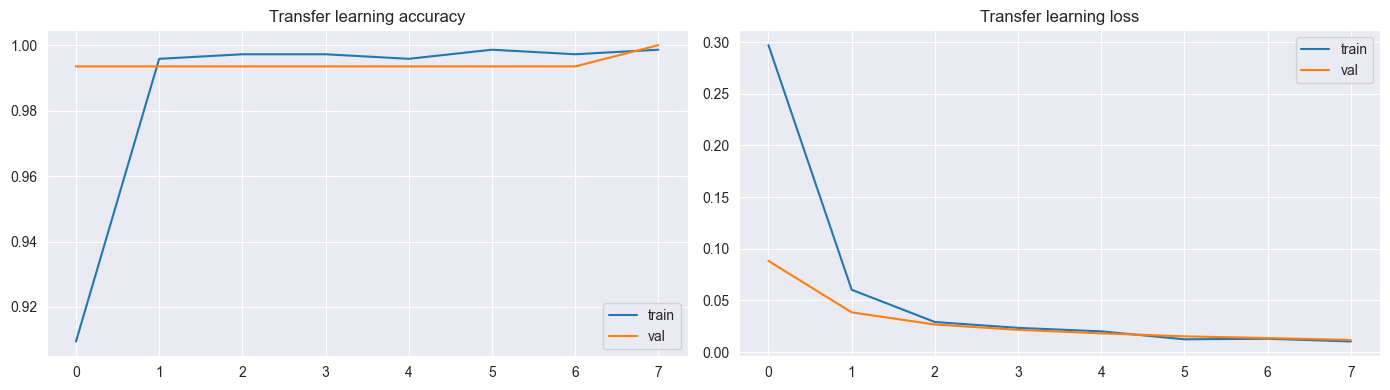

Transfer learning test accuracy: 1.0

Classification report for transfer model:
              precision    recall  f1-score   support

      horses       1.00      1.00      1.00        74
      humans       1.00      1.00      1.00        81

    accuracy                           1.00       155
   macro avg       1.00      1.00      1.00       155
weighted avg       1.00      1.00      1.00       155



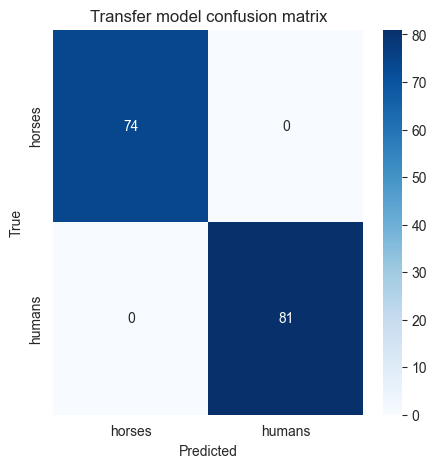

Summary of all test metrics:
        model   loss  accuracy
CNN v1 no aug 0.1478    0.9613
 CNN v1 + aug 0.0064    1.0000
 CNN v2 + aug 0.7790    0.5226
 CNN v3 + aug 0.6909    0.5226
Transfer learning test loss: 0.0062, accuracy: 1.0000


In [18]:
transfer_history = transfer_model.fit(
    transfer_train,
    validation_data=transfer_val,
    epochs=8,
    callbacks=callbacks_list,
    verbose=1
)

plot_history(transfer_history, 'Transfer learning')

transfer_test_loss, transfer_test_acc = transfer_model.evaluate(transfer_test, verbose=0)
print('Transfer learning test accuracy:', transfer_test_acc)


def evaluate_with_report(model, dataset, label_names):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_labels = (preds[:, 0] > 0.5).astype(int)
        y_true.extend(labels.numpy().tolist())
        y_pred.extend(pred_labels.tolist())

    print('\nClassification report for transfer model:')
    print(classification_report(y_true, y_pred, target_names=label_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title('Transfer model confusion matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


evaluate_with_report(transfer_model, transfer_test, ds_info.features['label'].names)

print('Summary of all test metrics:')
print(results_df.to_string(index=False, float_format='%.4f'))
print(f"Transfer learning test loss: {transfer_test_loss:.4f}, accuracy: {transfer_test_acc:.4f}")

# 11. Explainability with saliency maps

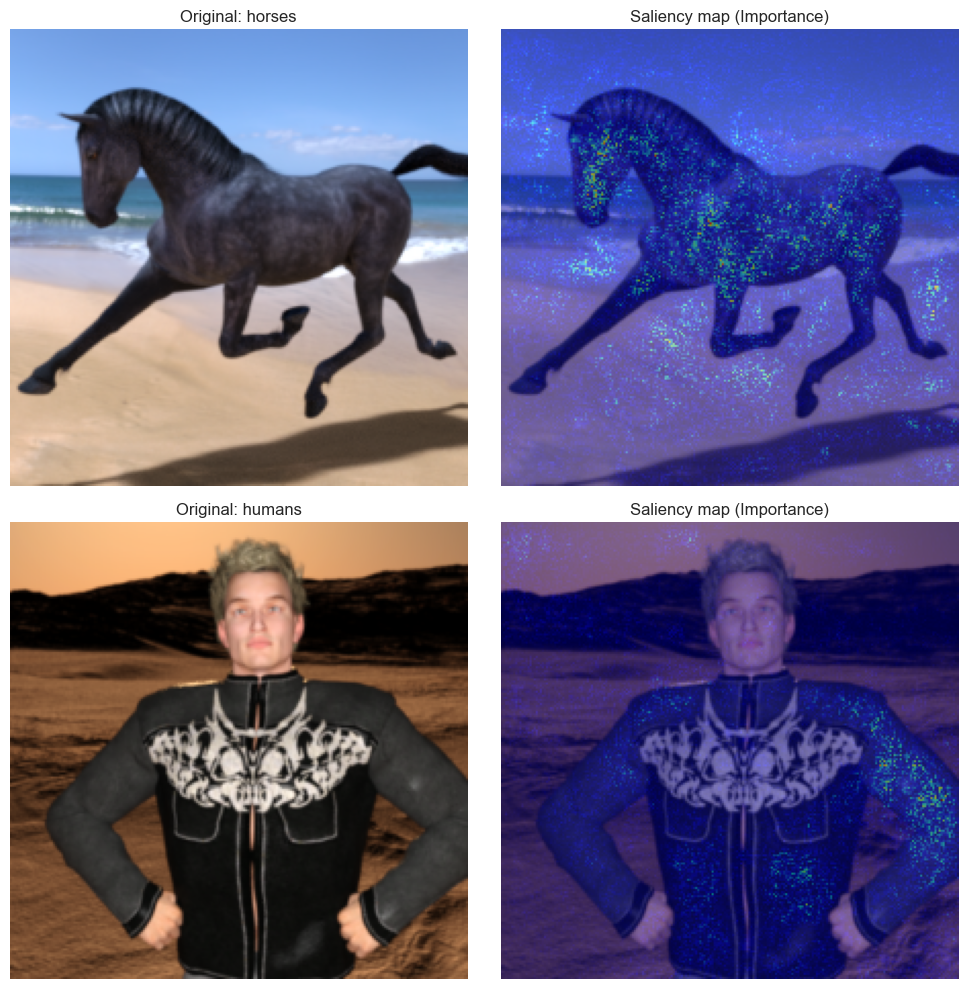

In [ ]:
def make_saliency_map(model, image_tensor, label_idx=None):
    image_tensor = tf.cast(tf.expand_dims(image_tensor, axis=0), tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        prediction = model(image_tensor)
        if label_idx is None:
            score = prediction[:, 0]
        else:
            score = prediction[:, label_idx]
            
    grads = tape.gradient(score, image_tensor)
    
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]
    return saliency

if 'transfer_test' not in globals():
    transfer_test = ds_test_raw.map(preprocess_transfer, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Візуалізація
for images, labels in transfer_test.take(1):
    num_examples = min(2, images.shape[0])
    plt.figure(figsize=(10, 10))

    for i in range(num_examples):
        sample_image = images[i]
        sample_label = labels[i]
        saliency = make_saliency_map(transfer_model, sample_image)
        img_plot = sample_image.numpy()
        img_min = img_plot.min()
        img_max = img_plot.max()
        normalized_img = (img_plot - img_min) / (img_max - img_min + 1e-8)

        plt.subplot(num_examples, 2, 2 * i + 1)
        plt.imshow(normalized_img)
        plt.title(f'Original: {ds_info.features["label"].names[sample_label.numpy()]}')
        plt.axis('off')

        plt.subplot(num_examples, 2, 2 * i + 2)
        plt.imshow(normalized_img)
        plt.imshow(saliency.numpy(), cmap='jet', alpha=0.5)
        plt.title('Saliency map (Importance)')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 12. Conclusions

У цьому ноутбуці показано реальні результати для датасету `horses_or_humans`.

- `CNN v1 no aug`: тестова точність 0.9613, тестова втрата 0.1478.
- `CNN v1 + aug`: тестова точність 1.0000, тестова втрата 0.0064.
- `CNN v2 + aug`: тестова точність 0.5226, тестова втрата 0.7790.
- `CNN v3 + aug`: тестова точність 0.5226, тестова втрата 0.6909.
- `MobileNetV2 transfer`: тестова точність 1.0000, тестова втрата 0.0062.

Основні висновки:
- Простий CNN з аугментацією (`CNN v1 + aug`) і transfer learning з `MobileNetV2` обидва дали 100% точності на тесті.
- Складніші кастомні моделі `CNN v2 + aug` та `CNN v3 + aug` не змогли узагальнити і показали тільки 52.26% точності, тому для цього датасету вони виявилися менш вдалими.
- Результати підтверджують, що аугментація має критичне значення для простої архітектури, а попередньо навчені фільтри з ImageNet дають дуже сильний фінішний результат.
- `CNN v1 + aug` краще за `CNN v1 no aug`, отже аугментація явно покращила узагальнення.
- `MobileNetV2 transfer` показує ідеальну класифікацію на тесті, що підтверджується класифікаційним звітом і confusion matrix.
- Для цієї задачі найкращі підходи — або простий CNN з аугментацією, або transfer learning на основі MobileNetV2.

Аналіз Saliency Maps (Explainability):

Побудовані карти уваги (Saliency Maps) наочно демонструють, на які саме пікселі зображення найбільше спирається модель MobileNetV2 при прийнятті рішень.

На візуалізаціях видно, що найвищі значення градієнтів зосереджені безпосередньо на ключових ознаках об'єктів (наприклад, силуети, голови або ноги коней, а також обриси тіла та обличчя людей). Фоновим елементам (трава, небо тощо) модель приділяє мінімальну увагу.

Це підтверджує, що модель вивчила правильні семантичні ознаки для розпізнавання класів.